In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def ds9_regions(coords, opening=5):
    with open("D:\ds9_new.reg", "w") as f:
        f.write("# Region file format: DS9 version 4.1\n")
        f.write("global color=green\n")
        f.write("fk5\n")
        for i, (_, x, y) in enumerate(coords):
            f.write(f'circle({x},{y},{opening}")\n')
            f.write(f'circle({x},{y},{opening/100}")\n')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_4120\2020934162.py:2: SyntaxWarning: invalid escape sequence '\d'
  with open("D:\ds9_new.reg", "w") as f:


In [3]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [4]:
df_total = pd.read_pickle('../../all_fluxes_DES.pkl')

In [5]:
df_total.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'FLUX_DES-R_0.5FWHM', 'FLUXERR_DES-R_0.5FWHM', 'FLUX_DES-Z_0.5FWHM',
       'FLUXERR_DES-Z_0.5FWHM', 'FLUX_DES-I_0.5FWHM', 'FLUXERR_DES-I_0.5FWHM',
       'FLUX_DES-G_0.5FWHM', 'FLUXERR_DES-G_0.5FWHM', 'FLUX_NIR-H_0.5FWHM',
       'FLUXERR_NIR-H_0.5FWHM', 'FLUX_NIR-Y_0.5FWHM', 'FLUXERR_NIR-Y_0.5FWHM',
       'FLUX_NIR-J_0.5FWHM', 'FLUXERR_NIR-J_0.5FWHM', 'FLUX_VIS_0.5FWHM',
       'FLUXERR_VIS_0.5FWHM', 'FLUX_DES-I_1FWHM', 'FLUXERR_DES-I_1FWHM',
       'FLUX_DES-R_1FWHM', 'FLUXERR_DES-R_1FWHM', 'FLUX_DES-Z_1FWHM',
       'FLUXERR_DES-Z_1FWHM', 'FLUX_DES-G_1FWHM', 'FLUXERR_DES-G_1FWHM',
       'FLUX_NIR-J_1FWHM', 'FLUXERR_NIR-J_1FWHM', 'FLUX_NIR-Y_1FWHM',
       'FLUXERR_NIR-Y_1FWHM', 'FLUX_NIR-H_1FWHM', 'FLUXERR_NIR-H_1FWHM',
       'FLUX_VIS_1FWHM', 'FLUXERR_VIS_1FWHM', 'FLUX_DES-Z_2FWHM',
       'FLUXERR_DES-Z_2FWHM', 'FLUX_DES-R_2FWHM', 'FLUXERR_DES-R_2FWHM',
       'FLUX_DES-I_2FWHM', 'FLUXERR_DE

In [6]:
bands = ['DES-G','DES-R','DES-I','DES-Z','VIS','NIR-Y','NIR-J','NIR-H']
mask = pd.Series(True, index=df_total.index)

for FWHM in [0.5, 1, 2]:
    for b in bands:
        mask &= df_total[f'FLUX_{b}_{FWHM}FWHM'] / df_total[f'FLUXERR_{b}_{FWHM}FWHM'] > 5
df_sel = df_total[mask].copy()
print(len(df_sel), len(df_total))

245040 18389454


In [7]:
for FWHM in [0.5, 1, 2]:
    for b in bands:
        df_sel[f'MAG_{b}_{FWHM}FWHM'] = -2.5*np.log10(df_sel[f'FLUX_{b}_{FWHM}FWHM'])

In [8]:
for FWHM in [0.5, 1, 2]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']
df_sel = df_sel.copy()

C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_4120\3418644154.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']


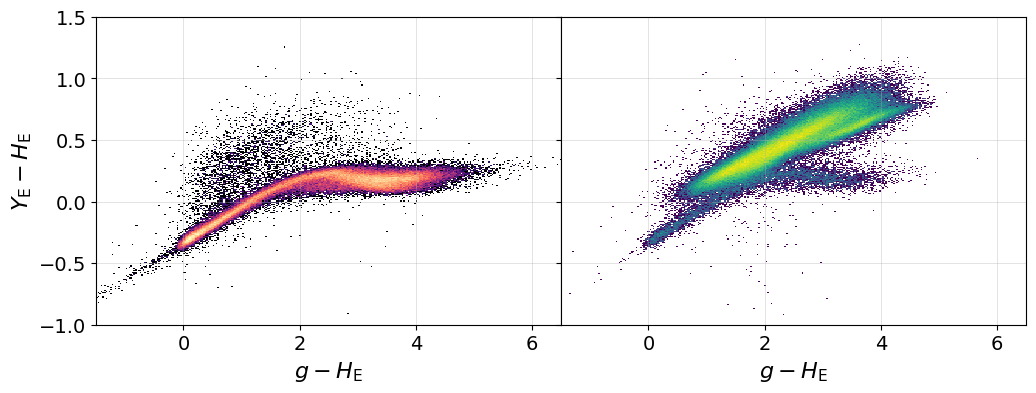

In [9]:
xmin, xmax = -1.5, 6.5
ymin, ymax = -1, 1.5
n_bins = 300
x_bins = np.linspace(xmin, xmax, n_bins + 1)
y_bins = np.linspace(ymin, ymax, n_bins + 1)
bins = (x_bins, y_bins)
x_color = 'DES-G-NIR-H_1FWHM'
y_color = 'NIR-Y-NIR-H_1FWHM'
mask = df_sel['point_source_probability_mer'] <= .7
fig, axes = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12, 4), gridspec_kw={'wspace': 0, 'hspace': 0})
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
mask = df_sel['point_source_probability_mer'] > .7
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
# plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
# plt.grid()
# plt.xlabel(x_color.replace('_', '-'))
# plt.ylabel(y_color.replace('_', '-
# '))
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(r'$g-H_\mathrm{E}$')
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(r'$Y_\mathrm{E}-H_\mathrm{E}$')
# plt.savefig('psp_hist.png')
plt.show()

In [10]:
features = []
for FWHM in [1]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            features.append(f'{bands[i]}-{bands[j]}_{FWHM}FWHM')
X = df_sel[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
print(len(X), len(df_sel))
print(features)

245040 245040
['DES-G-DES-R_1FWHM', 'DES-G-DES-I_1FWHM', 'DES-G-DES-Z_1FWHM', 'DES-G-VIS_1FWHM', 'DES-G-NIR-Y_1FWHM', 'DES-G-NIR-J_1FWHM', 'DES-G-NIR-H_1FWHM', 'DES-R-DES-I_1FWHM', 'DES-R-DES-Z_1FWHM', 'DES-R-VIS_1FWHM', 'DES-R-NIR-Y_1FWHM', 'DES-R-NIR-J_1FWHM', 'DES-R-NIR-H_1FWHM', 'DES-I-DES-Z_1FWHM', 'DES-I-VIS_1FWHM', 'DES-I-NIR-Y_1FWHM', 'DES-I-NIR-J_1FWHM', 'DES-I-NIR-H_1FWHM', 'DES-Z-VIS_1FWHM', 'DES-Z-NIR-Y_1FWHM', 'DES-Z-NIR-J_1FWHM', 'DES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']


In [11]:
X_subset = StandardScaler().fit_transform(X)

In [12]:
embedding_2d = umap.UMAP(
    n_neighbors=50,
    min_dist=0
).fit_transform(X_subset)

In [13]:
clusterer = HDBSCAN(
    min_cluster_size=1000,
    min_samples=50
)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([0, 1]), array([ 76480, 168560]))


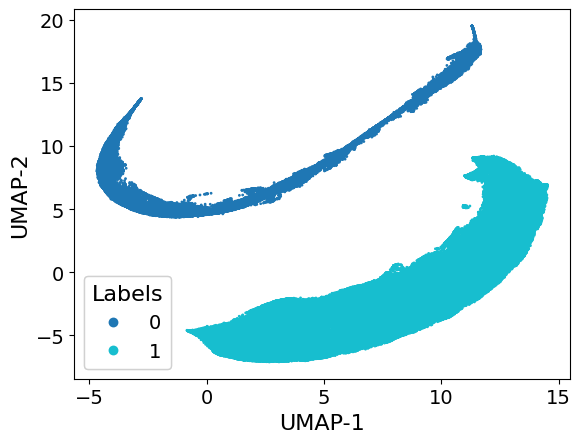

In [14]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_splitting_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_splitting_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

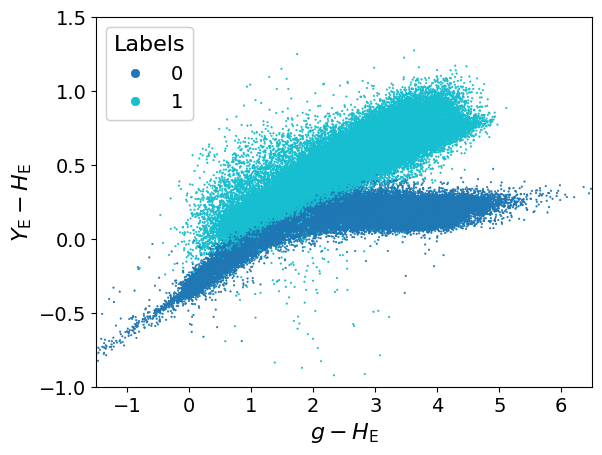

In [15]:
mask = labels != -1

scatter = plt.scatter(
    df_sel['DES-G-NIR-H_1FWHM'][mask],
    df_sel['NIR-Y-NIR-H_1FWHM'][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    label='DBSCAN',
    rasterized=True
)

legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.xlabel(r'$g-H_\mathrm{E}$')
plt.ylabel(r'$Y_\mathrm{E}-H_\mathrm{E}$')
plt.xlim(-1.5, 6.5)
plt.ylim(-1, 1.5)
plt.savefig('../../results/figures/analysis/color_color_splitting_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/color_color_splitting_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [16]:
# colors_list = []
# for FWHM in [1]:
#     for i in range(len(bands)-1):
#         for j in range(i+1, len(bands)):
#             colors_list.append(f'{bands[i]}-{bands[j]}_{FWHM}FWHM')
# colors = df_sel.iloc[idx][colors_list]

In [17]:
# group_mask = labels == 2
# group = colors[group_mask]
# other = colors[~group_mask]
# group_mean = group.mean(axis=0)
# rest_mean = other.mean(axis=0)
#
# global_std = colors.std(axis=0)
#
# delta = (group_mean - rest_mean) / global_std
#
# importance = pd.Series(
#     delta,
#     index=colors_list
# ).sort_values(key=np.abs, ascending=False)
#
# print(importance)

In [18]:
# mask = labels == 0
# x_color = 'DES-G-NIR-H_1FWHM'
# y_color = 'NIR-J-NIR-H_1FWHM'
#
# x_min, x_max = -1, 6
# y_min, y_max = -1, 2
# scatter = plt.scatter(
#     df_sel[x_color].iloc[idx][mask],
#     df_sel[y_color].iloc[idx][mask],
#     c=df_sel['point_source_probability_mer'].iloc[idx][mask],
#     s=1,
#     marker='o',
#     label='DBSCAN'
# )
# plt.xlabel("UMAP-1")
# plt.ylabel("UMAP-2")
# plt.title("DBSCAN Clusters")
# plt.xlim(x_min, x_max)
# plt.ylim(y_min, y_max)
# plt.colorbar()
# plt.show()
# scatter = plt.scatter(
#     df_sel[x_color].iloc[idx][~mask],
#     df_sel[y_color].iloc[idx][~mask],
#     c=df_sel['point_source_probability_mer'].iloc[idx][~mask],
#     s=1,
#     marker='o',
#     label='DBSCAN'
# )
#
# plt.xlabel("UMAP-1")
# plt.ylabel("UMAP-2")
# plt.title("DBSCAN Clusters")
# plt.xlim(x_min, x_max)
# plt.ylim(y_min, y_max)
# plt.colorbar()
# plt.show()

In [19]:
galaxy = df_sel[labels==1]
star = df_sel[labels==0]

In [20]:
pd.to_pickle(galaxy, 'galaxy_south.pkl')
pd.to_pickle(star, 'star_south.pkl')

In [48]:
galaxy =  pd.read_pickle('galaxy_south.pkl')
star =  pd.read_pickle('star_south.pkl')

In [49]:
selection = galaxy

In [50]:
bands = ['DES-G', 'DES-R', 'DES-I', 'DES-Z', 'VIS', 'NIR-Y', 'NIR-J', 'NIR-H']
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [51]:
features = ['DES-G-DES-R_1FWHM', 'DES-G-DES-I_1FWHM', 'DES-G-DES-Z_1FWHM', 'DES-G-VIS_1FWHM', 'DES-G-NIR-Y_1FWHM', 'DES-G-NIR-J_1FWHM', 'DES-G-NIR-H_1FWHM', 'DES-R-DES-I_1FWHM', 'DES-R-DES-Z_1FWHM', 'DES-R-VIS_1FWHM', 'DES-R-NIR-Y_1FWHM', 'DES-R-NIR-J_1FWHM', 'DES-R-NIR-H_1FWHM', 'DES-I-DES-Z_1FWHM', 'DES-I-VIS_1FWHM', 'DES-I-NIR-Y_1FWHM', 'DES-I-NIR-J_1FWHM', 'DES-I-NIR-H_1FWHM', 'DES-Z-VIS_1FWHM', 'DES-Z-NIR-Y_1FWHM', 'DES-Z-NIR-J_1FWHM', 'DES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]

In [52]:
Xn = StandardScaler().fit_transform(X)

In [53]:
embedding_2d = umap.UMAP(
    n_neighbors=10,
    min_dist=0.0
).fit_transform(Xn)

In [54]:
clusterer = HDBSCAN(min_cluster_size=100,
                    min_samples=10, n_jobs=5)
clusterer = DBSCAN(eps=0.2)

# labels = clusterer.fit_predict(embedding_2d)
# labels[labels == 1] = 1000
labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2]), array([     2, 165564,   2989,      5]))


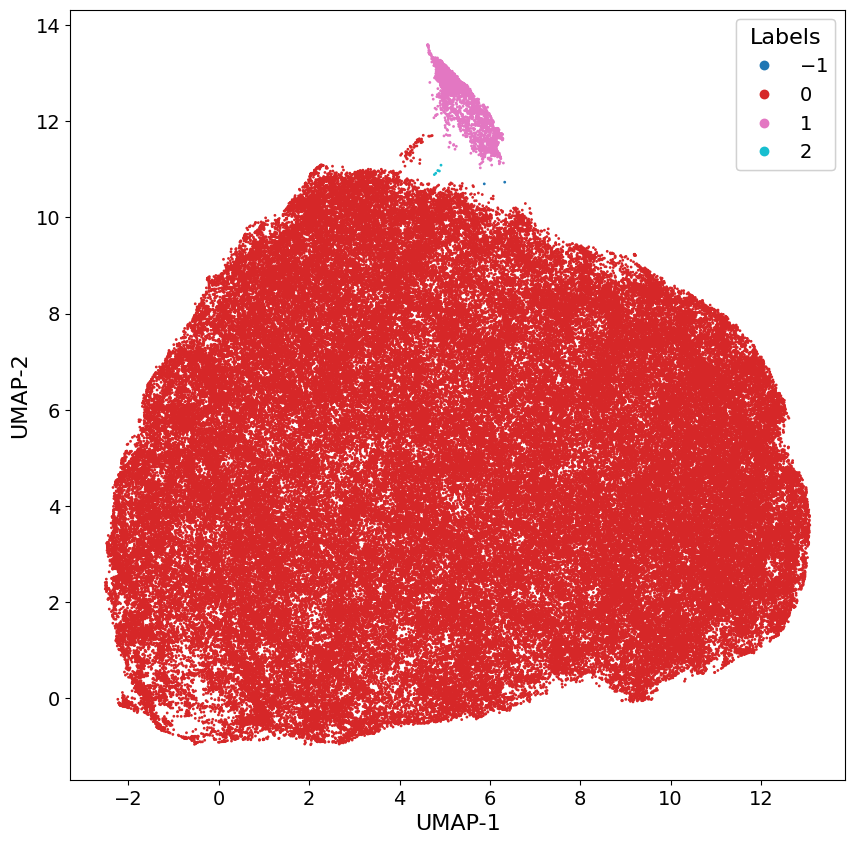

In [55]:
plt.figure(figsize=(10,10))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_galaxy_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_galaxy_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

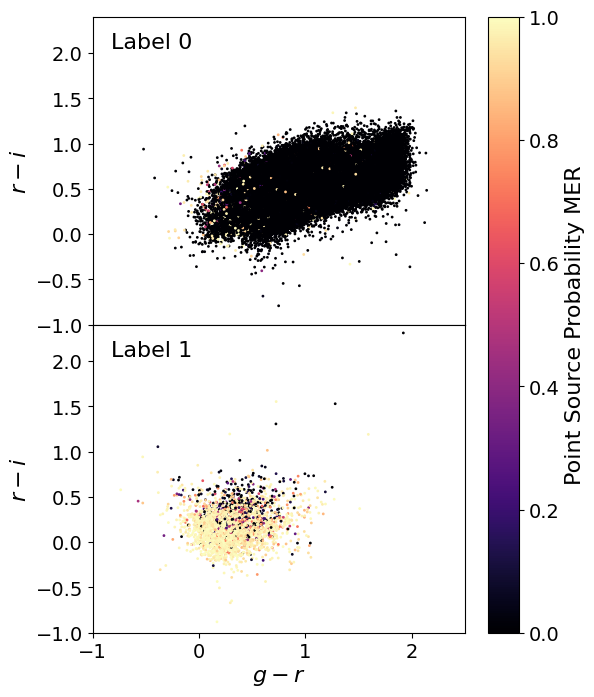

In [58]:
mask = labels == 1
x_color = 'DES-G-DES-R_1FWHM'
y_color = 'DES-R-DES-I_1FWHM'

fig, axes = plt.subplots(2,1, sharey=True, sharex=True, figsize=(6,8), gridspec_kw={'wspace': 0, 'hspace': 0})

x_min, x_max = -1, 2.5
y_min, y_max = -1, 2.4
for i in range(2):
    mask = labels == i
    sc1  = axes[i].scatter(
        selection[x_color][mask],
        selection[y_color][mask],
        c=selection['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN',
        rasterized=True
    )
    axes[i].text(
    0.05, 0.95, f"Label {i}",
    transform=axes[i].transAxes,
    va="top"
)
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
# axes[0].text(
#     0.05, 0.95, "Label 1",
#     transform=axes[0].transAxes,
#     va="top"
# )
#
# axes[1].text(
#     0.05, 0.95, "Label 0",
#     transform=axes[1].transAxes,
#     va="top"
# )
axes[1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
plt.savefig('../../results/figures/analysis/color_color_galaxy_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/color_color_galaxy_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [59]:
quasar = selection[labels == 1]
not_quasar = selection[labels == 0]

In [60]:
# sel = galaxy.sort_values(by='FWHM').iloc[:-1]
sel = quasar.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
ds9_regions(coords[coords[:, 0] == 102021503], 5)

102021015.0 33
np.array([
    (61.944800, -48.754218),
    (61.705004, -48.743962),
    (62.252437, -48.736330),
    (62.034203, -48.693747),
    (62.027881, -48.667500),
    (62.331304, -48.630150),
    (61.733191, -48.620326),
    (62.144124, -48.602567),
    (61.794669, -48.590871),
    (61.789696, -48.560969),
    (61.853357, -48.546360),
    (62.004446, -48.537839),
    (62.258946, -48.536271),
    (61.822448, -48.533229),
    (62.237437, -48.514169),
    (61.788266, -48.493730),
    (61.985356, -48.492064),
    (61.976980, -48.479446),
    (61.991802, -48.442546),
    (62.219117, -48.429345),
    (62.091518, -48.417555),
    (61.893178, -48.409420),
    (61.831541, -48.386977),
    (61.713796, -48.378196),
    (61.805121, -48.378064),
])


In [32]:
sel = not_quasar.sort_values(by='FWHM', ascending=False).iloc[:-1]
# sel = not_quasar.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
ds9_regions(coords[coords[:, 0] == 102021503], 5)

102022484.0 1895
np.array([
    (66.329029, -47.233060),
    (66.341648, -47.239398),
    (66.340825, -47.242630),
    (66.326085, -47.224623),
    (66.338238, -47.196928),
    (66.389840, -47.209039),
    (66.386783, -47.205538),
    (66.317500, -47.131660),
    (66.365701, -47.207730),
    (66.401070, -47.204082),
    (66.324033, -47.154759),
    (66.369157, -47.204833),
    (66.405992, -47.244112),
    (66.405575, -47.122258),
    (66.315117, -47.041533),
    (66.303176, -47.197849),
    (66.312843, -47.237654),
    (66.392998, -47.121737),
    (66.333734, -47.253050),
    (66.327000, -47.100417),
    (66.379167, -47.243661),
    (66.294917, -47.196670),
    (66.330130, -47.121708),
    (66.351099, -47.106183),
    (66.298762, -47.191127),
    (66.417283, -47.116832),
    (66.342123, -47.107440),
    (66.353561, -47.222638),
    (66.363819, -47.210927),
    (66.302973, -47.194458),
    (66.238171, -47.121258),
    (66.349048, -47.150697),
    (66.350992, -47.153567),
    (66.353030,

In [61]:
selection = star

In [62]:
bands = ['DES-G', 'DES-R', 'DES-I', 'DES-Z', 'VIS', 'NIR-Y', 'NIR-J', 'NIR-H']
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [63]:
features = ['DES-G-DES-R_1FWHM', 'DES-G-DES-I_1FWHM', 'DES-G-DES-Z_1FWHM', 'DES-G-VIS_1FWHM', 'DES-G-NIR-Y_1FWHM', 'DES-G-NIR-J_1FWHM', 'DES-G-NIR-H_1FWHM', 'DES-R-DES-I_1FWHM', 'DES-R-DES-Z_1FWHM', 'DES-R-VIS_1FWHM', 'DES-R-NIR-Y_1FWHM', 'DES-R-NIR-J_1FWHM', 'DES-R-NIR-H_1FWHM', 'DES-I-DES-Z_1FWHM', 'DES-I-VIS_1FWHM', 'DES-I-NIR-Y_1FWHM', 'DES-I-NIR-J_1FWHM', 'DES-I-NIR-H_1FWHM', 'DES-Z-VIS_1FWHM', 'DES-Z-NIR-Y_1FWHM', 'DES-Z-NIR-J_1FWHM', 'DES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]

In [64]:
print(len(X), len(star))

76480 76480


In [65]:
Xn = StandardScaler().fit_transform(X)

In [66]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0
).fit_transform(Xn)

In [67]:
embedding = umap.UMAP(
    n_neighbors=5,
    min_dist=0,
    n_components=10
).fit_transform(Xn)

In [68]:
clusterer = HDBSCAN(
    min_cluster_size=1000,
    min_samples=5,
)
clusterer = DBSCAN(eps=0.2)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1]), array([   22, 68132,  8326]))


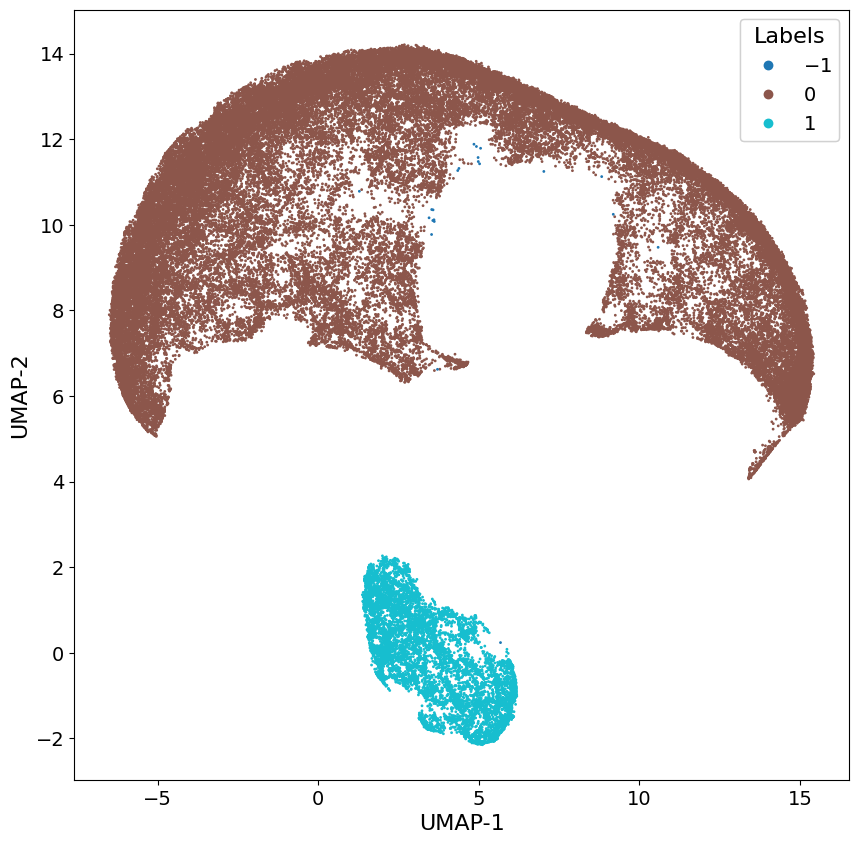

In [69]:
plt.figure(figsize=(10,10))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True,
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_star_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_star_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

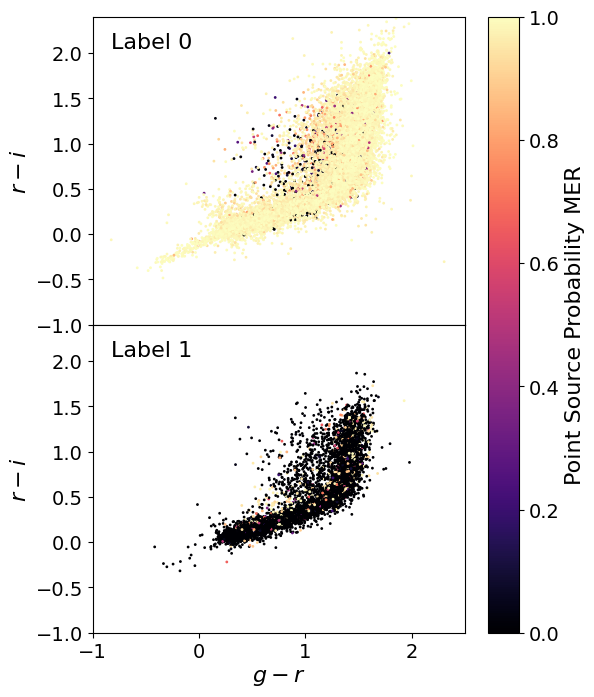

In [72]:
mask = labels == 0
x_color = 'DES-G-DES-R_1FWHM'
y_color = 'DES-R-DES-I_1FWHM'

fig, axes = plt.subplots(2,1, sharey=True, sharex=True, figsize=(6,8), gridspec_kw={'wspace': 0, 'hspace': 0})

x_min, x_max = -1, 2.5
y_min, y_max = -1, 2.4
for i in range(2):
    mask = labels == i
    sc1  = axes[i].scatter(
        star[x_color][mask],
        star[y_color][mask],
        c=star['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN',
        rasterized=True
    )
    axes[i].text(
    0.05, 0.95, f"Label {i}",
    transform=axes[i].transAxes,
    va="top"
)
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
axes[-1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
plt.savefig('../../results/figures/analysis/color_color_star_south.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/color_color_star_south.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [43]:
extended_star = star[labels==1]
not_extended_star = star[labels==0]
extra_stars = star[labels==2]

In [44]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
ds9_regions(coords[coords[:, 0] == 102021503], 5)

102021503.0 138
np.array([
    (65.956446, -48.241935),
    (65.662490, -48.237704),
    (65.692855, -48.233093),
    (65.657887, -48.224659),
    (65.668926, -48.220394),
    (65.612766, -48.217683),
    (65.596098, -48.214712),
    (65.962768, -48.212978),
    (65.839166, -48.207055),
    (65.963225, -48.201755),
    (65.979917, -48.195878),
    (65.862935, -48.195833),
    (65.890370, -48.194375),
    (65.654635, -48.194737),
    (65.655475, -48.191083),
    (65.673969, -48.186705),
    (65.818288, -48.180312),
    (66.150066, -48.178110),
    (65.868530, -48.173386),
    (66.036904, -48.170212),
    (66.035678, -48.162977),
    (65.926001, -48.161260),
    (65.814546, -48.159971),
    (65.558988, -48.155717),
    (65.625763, -48.154671),
    (66.021617, -48.152014),
    (65.921084, -48.146664),
    (65.875875, -48.144368),
    (65.565403, -48.140650),
    (66.045582, -48.137077),
    (66.022181, -48.135252),
    (65.724489, -48.134859),
    (65.591198, -48.128274),
    (65.738657, 

In [45]:
sel = not_extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

102021019.0 673
np.array([
    (64.697407, -48.749992),
    (65.334200, -48.749849),
    (65.101961, -48.748139),
    (65.128513, -48.748086),
    (64.711771, -48.745801),
    (64.938372, -48.745070),
    (64.660974, -48.744213),
    (64.916269, -48.744525),
    (65.236647, -48.743961),
    (64.672688, -48.743165),
    (64.783073, -48.742480),
    (64.665040, -48.741983),
    (65.358012, -48.741479),
    (65.153274, -48.738325),
    (64.813293, -48.737782),
    (65.172805, -48.737813),
    (65.063943, -48.737871),
    (64.876418, -48.737415),
    (64.979576, -48.736298),
    (64.857181, -48.735202),
    (65.085177, -48.734734),
    (65.363193, -48.734192),
    (65.058709, -48.734129),
    (64.751285, -48.733670),
    (65.332645, -48.732183),
    (64.868547, -48.730834),
    (64.807051, -48.730233),
    (64.865484, -48.729865),
    (64.718120, -48.728753),
    (64.838080, -48.728635),
    (64.706665, -48.727152),
    (64.923633, -48.726853),
    (65.070857, -48.726660),
    (64.926127, 

In [46]:
sel = extra_stars.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

102020058.0 10
np.array([
    (58.552493, -49.712062),
    (58.905001, -49.663038),
    (58.905140, -49.662872),
    (58.762452, -49.620243),
    (58.767647, -49.617721),
    (58.766989, -49.616918),
    (58.767647, -49.615383),
    (58.673158, -49.566424),
    (59.023045, -49.561339),
    (59.055663, -49.306203),
])


In [60]:
pd.to_pickle(quasar, 'classes/quasar_south.pkl')
pd.to_pickle(not_quasar, 'classes/non_quasar_south.pkl')
pd.to_pickle(extended_star, 'classes/extended_star_south.pkl')
pd.to_pickle(not_extended_star, 'classes/not_extended_star_south.pkl')
pd.to_pickle(extra_stars, 'classes/extra_stars_south.pkl')

### JUST ANALYZING THE CLASSES

In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob
from astropy.io import fits
from astropy.table import Table

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def ds9_regions(coords, opening=5):
    with open("D:\ds9_new.reg", "w") as f:
        f.write("# Region file format: DS9 version 4.1\n")
        f.write("global color=green\n")
        f.write("fk5\n")
        for i, (_, x, y) in enumerate(coords):
            f.write(f'circle({x},{y},{opening}")\n')
            f.write(f'circle({x},{y},{opening/100}")\n')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_22404\2020934162.py:2: SyntaxWarning: invalid escape sequence '\d'
  with open("D:\ds9_new.reg", "w") as f:


In [20]:
quasar = pd.read_pickle('classes/quasar_south.pkl')
galaxy = pd.read_pickle('classes/non_quasar_south.pkl')
extended_star = pd.read_pickle('classes/extended_star_south.pkl')
star = pd.read_pickle('classes/not_extended_star_south.pkl')
# extra_stars = pd.read_pickle('classes/extra_stars_south.pkl')
cat = pd.read_pickle('all_class_data.pkl')

In [32]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
print(coords[coords[:, 0] == 102021503])
ds9_regions(coords[coords[:, 0] == 102021503])

203 8339
102021503.0 138
np.array([
    (65.956446, -48.241935),
    (65.662490, -48.237704),
    (65.692855, -48.233093),
    (65.657887, -48.224659),
    (65.668926, -48.220394),
    (65.612766, -48.217683),
    (65.596098, -48.214712),
    (65.962768, -48.212978),
    (65.839166, -48.207055),
    (65.963225, -48.201755),
    (65.979917, -48.195878),
    (65.862935, -48.195833),
    (65.890370, -48.194375),
    (65.654635, -48.194737),
    (65.655475, -48.191083),
    (65.673969, -48.186705),
    (65.818288, -48.180312),
    (66.150066, -48.178110),
    (65.868530, -48.173386),
    (66.036904, -48.170212),
    (66.035678, -48.162977),
    (65.926001, -48.161260),
    (65.814546, -48.159971),
    (65.558988, -48.155717),
    (65.625763, -48.154671),
])
[[ 1.02021503e+08  6.59564464e+01 -4.82419354e+01]
 [ 1.02021503e+08  6.56624901e+01 -4.82377036e+01]
 [ 1.02021503e+08  6.56928549e+01 -4.82330929e+01]
 [ 1.02021503e+08  6.56578867e+01 -4.82246589e+01]
 [ 1.02021503e+08  6.56689262e+0

In [5]:
df_total = pd.read_pickle('../../all_fluxes_DES.pkl')

In [29]:
matches = cat[cat['OBJECT_ID'].isin(star['id'])]
height, _ = np.histogram(matches['PHZ_CLASSIFICATION'], bins=np.arange(0, 10)-0.5, density=True)
labels = ['Not Accepted', 'Star', 'Galaxy', 'Star + Galaxy', 'QSO', 'QSO + Star', 'QSO + Galaxy', 'QSO + Star + Galaxy']

table = ''
for label, h in zip(labels, height):
    table += f"{label:<20} | {h * 100:.2f}%\n"

print(table)

Not Accepted         | 1.44%
Star                 | 81.60%
Galaxy               | 10.36%
Star + Galaxy        | 6.60%
QSO                  | 0.00%
QSO + Star           | 0.00%
QSO + Galaxy         | 0.00%
QSO + Star + Galaxy  | 0.00%



In [63]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.patches as patches
from astropy.visualization import ImageNormalize, ZScaleInterval, SqrtStretch

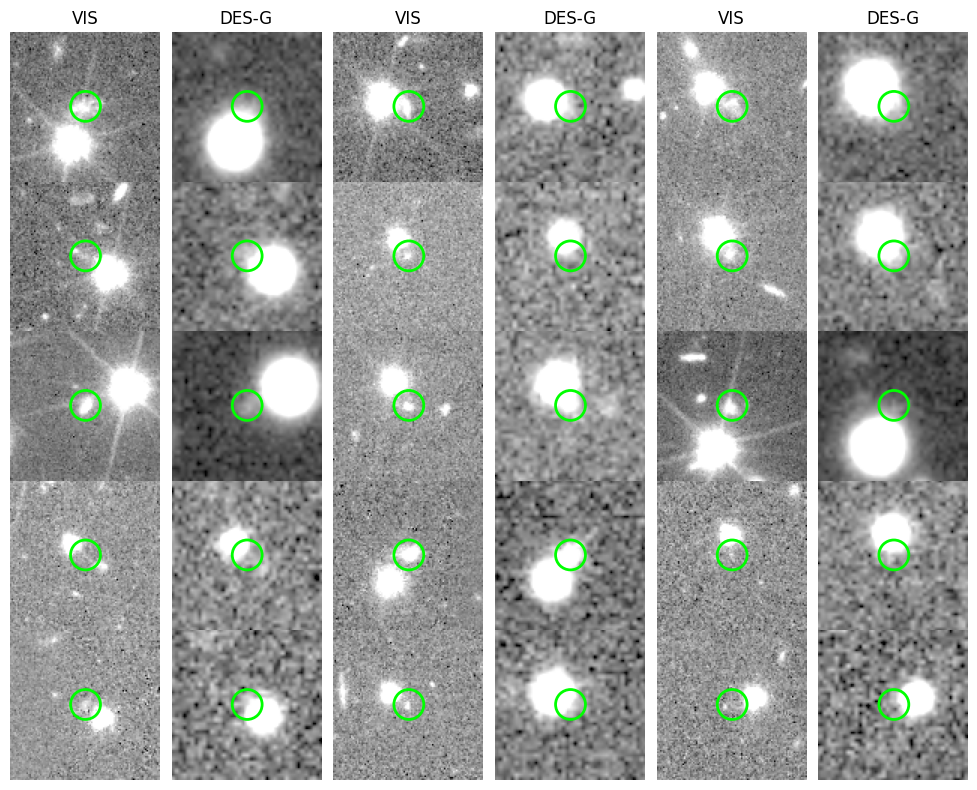

In [75]:
hdu2 = fits.open("D:/Q1_IMAGES/EUC_MER_BGSUB-MOSAIC-DES-G_TILE102021503-9378C4_20241018T150620.039814Z_00.00.fits")[0]
hdu1 = fits.open('D:/Q1_IMAGES/EUC_MER_BGSUB-MOSAIC-VIS_TILE102021503-2BB1EC_20241018T202746.094112Z_00.00.fits')[0]

data1 = hdu1.data
data2 = hdu2.data

wcs1 = WCS(hdu1.header)
wcs2 = WCS(hdu2.header)
fig, axes = plt.subplots(5, 6, figsize=(10, 8), gridspec_kw={'wspace': 0, 'hspace': 0})
# Object coordinates
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102021503]):
    if i == len(axes)*3:
        break

    position = SkyCoord(x*u.deg, y*u.deg)
    row = (i // 5)*2
    i %= 5
    size = (100, 100)  # pixels

    cutout1 = Cutout2D(data1, position, size, wcs=wcs1)
    cutout2 = Cutout2D(data2, position, size, wcs=wcs2)

    norm = ImageNormalize(
        cutout1.data,
        interval=ZScaleInterval(),
        stretch=SqrtStretch()
    )

    axes[i, 0+row].imshow(cutout1.data, origin="lower", norm=norm, cmap='grey')

    axes[i, 0+row].set_axis_off()

    norm = ImageNormalize(
        cutout2.data,
        interval=ZScaleInterval(),
        stretch=SqrtStretch()
    )
    axes[i, 1+row].imshow(cutout2.data, origin="lower", norm=norm, cmap='grey')

    axes[i, 1+row].set_axis_off()
h, w = cutout2.data.shape[:2]
center = (w / 2, h / 2)

for ax in axes.flatten():
    ax.add_patch(patches.Circle(
    center,
    radius=10,
    edgecolor='lime',
    facecolor='none',
    linewidth=2
))
axes[0, 0].set_title("VIS")
axes[0, 1].set_title("DES-G")
axes[0, 2].set_title("VIS")
axes[0, 3].set_title("DES-G")
axes[0, 4].set_title("VIS")
axes[0, 5].set_title("DES-G")
plt.tight_layout()
plt.show()


In [55]:
4//5

0